**1. Importing Dependencies**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**2. Load the Dataset**

In [2]:
df = pd.read_csv("/content/CLEANED_marketing_campaign_dataset.csv")

**3. Data Cleaning (Handling potential NULLs from SQL)**

In [3]:
df = df.dropna(subset=['acquisition_cost', 'roi_ratio'])

**4. Calculate Pearson Correlation, p-value, and t-statistic**

In [4]:
r, p_value = stats.pearsonr(df["acquisition_cost"], df["roi_ratio"])

# Pearsonr doesn't give t-stat directly, so we calculate it for our report


In [5]:
# Sample Size Finding
n = len(df)

In [6]:
# Calculating t-stat
t_stat = r * np.sqrt((n - 2) / (1 - r**2))

**5. Results Output**

In [7]:
print(f"--- Statistical Summary ---")
print(f"Sample Size (n): {n:,}")
print(f"Correlation Coefficient (r): {r:.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

--- Statistical Summary ---
Sample Size (n): 200,000
Correlation Coefficient (r): -0.4063
T-Statistic: -198.8508
P-Value: 0.0



**6. Visualization**

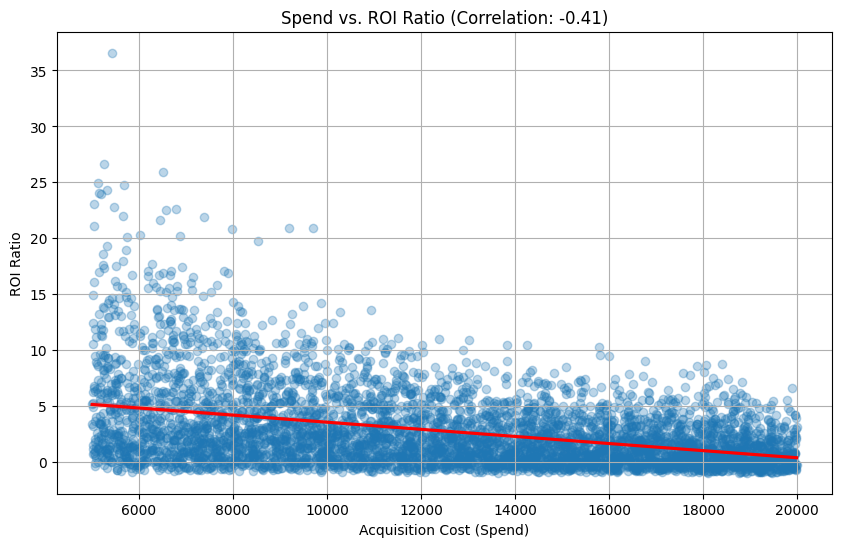

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='acquisition_cost', y='roi_ratio', data=df.sample(5000),
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Spend vs. ROI Ratio (Correlation: {r:.2f})')
plt.xlabel('Acquisition Cost (Spend)')
plt.ylabel('ROI Ratio')
plt.grid(True)
plt.show()

# Insights:

**Negative Correlation:**  There is a moderate negative correlation (r = -0.41) between 'acquisition_cost' and 'roi_ratio'. This suggests that as the acquisition cost (spend) increases, the ROI ratio tends to decrease.

**Statistical Significance:** The p-value of 0.0 (which is less than the common significance level of 0.05) indicates that this negative correlation is statistically significant. This means it's highly unlikely that this observed relationship occurred by random chance.

**Visualization Support:** The regression plot visually confirms this negative relationship, showing a downward trend where higher acquisition costs are associated with lower ROI ratios.

In essence, **the data suggests that there's a trade-off: spending more on customer acquisition might lead to a lower return on investment, on average.**